# "master instruction” (onderdeel van prompt — EDA-breed, dus voor elke EDA notebook (phase2))

Je werkt als senior research assistant voor een masterthesis in data analysis. Voor meer informatie over de thesis / onderzoeksvoorstel / opzet: bekijk bron "Geannoteerd_onderzoeksvoorstel.md" en voor extra gelinkte literatuur bron; "External factors and SHAP in Urban Parking copy.pdf" (beide bestanden zijn te vinden in de map 'literatuur_en_info' (binnen dit project)) 

voor structuur en gewenste flow check projectalomvattede: "README.md"

Context:
- Projectfase: Phase 2 — Exploratieve Data Analyse (EDA)
- Domein: parkeerbezetting van off-street parkings
- Doel: een academisch rigoureuze, reproduceerbare, hypothese-gedreven EDA uitvoeren die als uitstekende basis dient voor Phase 3 (Feature Engineering)
- Dataset(s): parquet-output uit Phase 1, met minstens MAD_shortterm en MAD_longterm
- Onderzoekslogica: tier-stratified analyse, met bijzondere aandacht voor temporal, spatial en external drivers
- Werkomgeving: VS Code + Jupyter notebooks
- Jij mag iteratief werken: je moet je eigen code-output lezen, interpreteren, evalueren, samenvatten, en op basis daarvan de volgende analytische stap bepalen

Belangrijke werkinstructies:
1. Werk notebook-native: schrijf steeds code in duidelijke, logisch gegroepeerde cellen.
2. Na elke analytische sectie moet je:
   - de output lezen,
   - een academische interpretatie geven,
   - expliciet vermelden welke hypothese(n) voorlopig ondersteund, verworpen of genuanceerd worden,
   - beslissen wat de volgende logische stap is.
3. Werk reproductief:
   - gebruik vaste paden/variabelen bovenaan,
   - schrijf nette helperfuncties indien nuttig,
   - vermijd rommelige eenmalige code.
4. Werk academisch:
   - beschrijf patronen voorzichtig,
   - maak onderscheid tussen descriptieve associatie en causale claim,
   - benoem beperkingen, datakwaliteit en mogelijke bias.
5. Indien je literatuur gebruikt:
   - voeg APA7-verwijzingen toe in markdown,
   - gebruik alleen controleerbare bronnen,
   - koppel hypotheses enkel aan literatuur als dat inhoudelijk verdedigbaar is.
6. Maak analyses direct nuttig voor Phase 3:
   - signaleer mogelijke feature candidates,
   - signaleer risico op leakage,
   - noteer niet-lineariteiten, interacties, segmentaties en transformaties.
7. Focus in EDA niet op “zoveel mogelijk grafieken”, maar op analytische waarde.
8. Rapporteer steeds ook wat NIET overtuigend blijkt.
9. Gebruik waar relevant robuuste statistiek, effectgroottes en multiple-testing-bewustzijn.
10. Sluit elk notebook af met een sectie:
   - "Key findings"
   - "Implications for feature engineering"
   - "Open questions for next notebook"

Technische stijlregels:
- Python: pandas, numpy, scipy, statsmodels, matplotlib, seaborn/plotly enkel indien functioneel, sklearn indien nodig
- Plotstijl: professioneel, leesbaar, consistente labels en units
- Timestamps correct behandelen
- (enkel indien expliciet handig, nodig, belangrijk) Segmentaties minstens per:
  - shortterm vs longterm
  - parking/tier/location category
  - event vs non-event
  - weekday/weekend
  - holiday/vacation/regular day waar relevant

Jouw taak is niet enkel code schrijven, maar ook analytisch denken als thesis-assistent.

## Notebook specifieke prompt

Doel van deze notebook: een globale, academisch interpreteerbare descriptieve basis leggen voor `MAD_shortterm` en `MAD_longterm`, zodat alle volgende EDA-notebooks op consistente en transparante descriptieve inzichten kunnen steunen.

## 0. Setup en data loading

In [1]:
from __future__ import annotations

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

pd.set_option("display.max_columns", 200)
pd.set_option("display.max_rows", 200)

sns.set_theme(style="whitegrid", context="notebook", palette="colorblind")


def find_project_root(start: Path | None = None) -> Path:
    current = (start or Path.cwd()).resolve()
    for candidate in (current, *current.parents):
        if (candidate / "data_processed").exists() and (candidate / "notebooks").exists():
            return candidate
    raise FileNotFoundError("Project root not found from current working directory")


PROJECT_ROOT = find_project_root()

# === AUTO-EXPORT ARTIFACTS (figures + displayed tables) ===
NOTEBOOK_SLUG = "eda_01_global_descriptives"
ARTIFACTS_DIR = PROJECT_ROOT / "artifacts" / "phase2" / NOTEBOOK_SLUG
FIG_DIR = ARTIFACTS_DIR / "figures"
TABLE_DIR = ARTIFACTS_DIR / "tables"
LOG_DIR = ARTIFACTS_DIR / "logs"

for _d in [ARTIFACTS_DIR, FIG_DIR, TABLE_DIR, LOG_DIR]:
    _d.mkdir(parents=True, exist_ok=True)


def _safe_artifact_name(name: str) -> str:
    allowed = set("abcdefghijklmnopqrstuvwxyzABCDEFGHIJKLMNOPQRSTUVWXYZ0123456789_-")
    s = "".join(ch if ch in allowed else "_" for ch in str(name))
    while "__" in s:
        s = s.replace("__", "_")
    s = s.strip("_")
    return s or "artifact"


def save_dataframe_artifact(df: pd.DataFrame, name: str, index: bool = True) -> dict[str, str | None]:
    base = _safe_artifact_name(name)
    csv_path = TABLE_DIR / f"{base}.csv"
    parquet_path = TABLE_DIR / f"{base}.parquet"

    df.to_csv(csv_path, index=index)
    parquet_ok = True
    try:
        df.to_parquet(parquet_path, index=index)
    except Exception:
        parquet_ok = False

    return {
        "csv": str(csv_path),
        "parquet": str(parquet_path) if parquet_ok else None,
    }


if not globals().get("_DISPLAY_AUTO_EXPORT_PATCHED", False):
    _DISPLAY_AUTO_EXPORT_PATCHED = True
    _ORIG_DISPLAY = display
    _DISPLAY_COUNTER = {"n": 0}

    def display(*objs, **kwargs):
        for obj in objs:
            if isinstance(obj, pd.DataFrame):
                _DISPLAY_COUNTER["n"] += 1
                save_dataframe_artifact(obj, f"display_{_DISPLAY_COUNTER['n']:03d}", index=True)
        return _ORIG_DISPLAY(*objs, **kwargs)


try:
    import matplotlib.pyplot as plt  # noqa: F401

    if not getattr(plt, "_AUTO_EXPORT_PATCHED", False):
        _ORIG_PLT_SHOW = plt.show
        _FIG_COUNTER = {"n": 0}

        def _show_and_save(*args, **kwargs):
            fig_nums = list(plt.get_fignums())
            for fig_num in fig_nums:
                fig = plt.figure(fig_num)
                _FIG_COUNTER["n"] += 1
                fig_path = FIG_DIR / f"fig_{_FIG_COUNTER['n']:03d}.png"
                fig.savefig(fig_path, dpi=150, bbox_inches="tight")
            return _ORIG_PLT_SHOW(*args, **kwargs)

        plt.show = _show_and_save
        plt._AUTO_EXPORT_PATCHED = True
    FIG_EXPORT_ENABLED = True
except Exception:
    FIG_EXPORT_ENABLED = False

print(f"Artifacts directory: {ARTIFACTS_DIR}")
print(f"- Figures: {FIG_DIR}")
print(f"- Tables: {TABLE_DIR}")

DATA_DIR = PROJECT_ROOT / "data_processed"

DATA_PATHS = {
    "shortterm": DATA_DIR / "MAD_shortterm.parquet",
    "longterm": DATA_DIR / "MAD_longterm.parquet",
}

raw_dfs = {}
for label, path in DATA_PATHS.items():
    if not path.exists():
        raise FileNotFoundError(f"Dataset ontbreekt: {label} -> {path}")
    df = pd.read_parquet(path).copy()
    df["dataset_label"] = label
    raw_dfs[label] = df

for label, df in raw_dfs.items():
    print(f"{label}: {df.shape[0]:,} rijen x {df.shape[1]:,} kolommen")

Artifacts directory: /Users/emilevandevoorde/Documents/mp_mechelen_parking_v2/artifacts/phase2/eda_01_global_descriptives
- Figures: /Users/emilevandevoorde/Documents/mp_mechelen_parking_v2/artifacts/phase2/eda_01_global_descriptives/figures
- Tables: /Users/emilevandevoorde/Documents/mp_mechelen_parking_v2/artifacts/phase2/eda_01_global_descriptives/tables
shortterm: 284,524 rijen x 67 kolommen
longterm: 46,643 rijen x 66 kolommen


**Interpretatie (initiele laadstap)**

Beide datasets zijn succesvol geladen en worden expliciet gelabeld (`dataset_label`) zodat shortterm en longterm in elke analyse vergelijkbaar blijven.

**Hypothese status**
- H0: De globale descriptieve analyse kan op beide MAD-datasets simultaan worden uitgevoerd. **Ondersteund**.

**Volgende logische stap**
- Een analytische dataversie opbouwen met consistente datetime-handling en eenduidige featuregroepering.

## 1. Analytische dataversie

In [2]:
TARGET_VARS = [
    "number_of_occupied_spaces",
    "number_of_spaces_override",
    "occupancy_rate",
    "total_capacity",
]

FEATURE_GROUPS = {
    "occupancy_core": ["number_of_occupied_spaces", "occupancy_rate"],
    "capacity_core": ["number_of_spaces_override", "total_capacity"],
    "segment_keys": ["dataset_label", "kind", "parking_type", "parking_location_category", "year", "parking_id"],
    "time_keys": ["rounded_hour", "date_only", "hour", "weekday_int", "month", "year"],
}

analytic_df = pd.concat(raw_dfs.values(), ignore_index=True)

for col in ["rounded_hour", "date_only"]:
    analytic_df[col] = pd.to_datetime(analytic_df[col], errors="coerce")

analytic_df["year"] = pd.to_numeric(analytic_df["year"], errors="coerce").astype("Int64")
analytic_df["year_from_ts"] = analytic_df["rounded_hour"].dt.year.astype("Int64")
analytic_df["year_mismatch"] = (
    analytic_df["year"].notna()
    & analytic_df["year_from_ts"].notna()
    & analytic_df["year"].ne(analytic_df["year_from_ts"])
)

analytic_df["dataset_kind_label"] = (
    analytic_df["dataset_label"].astype("string")
    + "_"
    + analytic_df["kind"].astype("string")
)

analytic_df["occupancy_band"] = pd.cut(
    analytic_df["occupancy_rate"],
    bins=[-0.001, 0.2, 0.4, 0.6, 0.8, 1.001],
    labels=["0-20%", "20-40%", "40-60%", "60-80%", "80-100%"],
    include_lowest=True,
)

analytic_df["capacity_tertile"] = pd.qcut(
    analytic_df["total_capacity"],
    q=3,
    labels=["small", "medium", "large"],
    duplicates="drop",
)

analytic_df = analytic_df.sort_values(["dataset_label", "parking_id", "rounded_hour"]).reset_index(drop=True)
analytic_df["abs_hourly_occ_change"] = (
    analytic_df.groupby(["dataset_label", "parking_id"])["occupancy_rate"]
    .diff()
    .abs()
)

analytic_overview = analytic_df.groupby("dataset_label").agg(
    n_rows=("occupancy_rate", "size"),
    n_parkings=("parking_id", "nunique"),
    date_min=("rounded_hour", "min"),
    date_max=("rounded_hour", "max"),
    year_min=("year", "min"),
    year_max=("year", "max"),
)
display(analytic_overview)

print("Aantal jaar-mismatches (year vs rounded_hour.year):", int(analytic_df["year_mismatch"].sum()))

missing_targets = (
    analytic_df.groupby("dataset_label")[TARGET_VARS]
    .apply(lambda d: d.isna().mean().mul(100).round(4))
)
print("\nMissingness (%) in targetvariabelen")
display(missing_targets)

for group_name, columns in FEATURE_GROUPS.items():
    present = [c for c in columns if c in analytic_df.columns]
    print(f"{group_name}: {present}")

,n_rows,n_parkings,date_min,date_max,year_min,year_max
dataset_label,,,,,,
longterm,46643,7,2024-01-01 00:00:00,2024-12-31 22:00:00,2024,2024
shortterm,284524,10,2018-12-31 23:00:00,2026-02-02 00:00:00,2018,2026


Aantal jaar-mismatches (year vs rounded_hour.year): 0

Missingness (%) in targetvariabelen


,number_of_occupied_spaces,number_of_spaces_override,occupancy_rate,total_capacity
dataset_label,,,,
longterm,0.0,0.0,0.0,0.0
shortterm,0.0,0.0,0.0,0.0


occupancy_core: ['number_of_occupied_spaces', 'occupancy_rate']
capacity_core: ['number_of_spaces_override', 'total_capacity']
segment_keys: ['dataset_label', 'kind', 'parking_type', 'parking_location_category', 'year', 'parking_id']
time_keys: ['rounded_hour', 'date_only', 'hour', 'weekday_int', 'month', 'year']


**Interpretatie**

Datetime-handling is consistent opgezet (`rounded_hour`, `date_only`) en er zijn geen detecteerbare jaar-mismatches tussen kalenderjaar en timestampjaar. Voor de kernvariabelen in deze notebook is er geen missingness, waardoor globale descriptieve vergelijking niet door imputatie wordt gedomineerd.

**Hypothese status**
- H1: Een uniforme analytische basis voor shortterm en longterm is haalbaar zonder extra harmonisatiestappen. **Ondersteund**.

**Volgende logische stap**
- De globale verdelingen en robuuste descriptieve statistieken van de vier kernvariabelen uitwerken.

## 2. Globale distributies en robuuste descriptives

In [3]:
def iqr_outlier_pct(series: pd.Series) -> float:
    s = pd.to_numeric(series, errors="coerce").dropna()
    if s.empty:
        return np.nan
    q1, q3 = s.quantile([0.25, 0.75])
    iqr = q3 - q1
    if iqr == 0:
        return 0.0
    low = q1 - 1.5 * iqr
    high = q3 + 1.5 * iqr
    return float(((s < low) | (s > high)).mean() * 100)


def robust_stats(series: pd.Series) -> dict[str, float]:
    s = pd.to_numeric(series, errors="coerce").dropna()
    if s.empty:
        return {k: np.nan for k in [
            "n", "mean", "median", "std", "iqr", "mad", "skew", "kurtosis", "min", "q01", "q95", "q99", "max", "cv", "iqr_outlier_pct"
        ]}

    q1, q3 = s.quantile([0.25, 0.75])
    mean = float(s.mean())
    std = float(s.std())

    return {
        "n": float(s.shape[0]),
        "mean": mean,
        "median": float(s.median()),
        "std": std,
        "iqr": float(q3 - q1),
        "mad": float((s - s.median()).abs().median()),
        "skew": float(s.skew()),
        "kurtosis": float(s.kurtosis()),
        "min": float(s.min()),
        "q01": float(s.quantile(0.01)),
        "q95": float(s.quantile(0.95)),
        "q99": float(s.quantile(0.99)),
        "max": float(s.max()),
        "cv": float(std / mean) if mean != 0 else np.nan,
        "iqr_outlier_pct": iqr_outlier_pct(s),
    }


rows = []
for dataset_label, grp in analytic_df.groupby("dataset_label"):
    for var in TARGET_VARS:
        row = {"dataset_label": dataset_label, "variable": var}
        row.update(robust_stats(grp[var]))
        rows.append(row)

overall_descriptives = pd.DataFrame(rows).sort_values(["variable", "dataset_label"]).set_index(["variable", "dataset_label"])
display(overall_descriptives.round(4))

fence_rows = []
for dataset_label, grp in analytic_df.groupby("dataset_label"):
    for var in TARGET_VARS:
        s = pd.to_numeric(grp[var], errors="coerce").dropna()
        q1, q3 = s.quantile([0.25, 0.75])
        iqr = q3 - q1
        low = q1 - 1.5 * iqr
        high = q3 + 1.5 * iqr
        fence_rows.append(
            {
                "dataset_label": dataset_label,
                "variable": var,
                "q1": q1,
                "q3": q3,
                "iqr": iqr,
                "lower_fence": low,
                "upper_fence": high,
                "iqr_outlier_pct": iqr_outlier_pct(s),
            }
        )

outlier_fences = pd.DataFrame(fence_rows).set_index(["variable", "dataset_label"])
print("IQR-fences en outlier percentages")
display(outlier_fences.round(4))

n      mean    median  \
variable                  dataset_label                                 
number_of_occupied_spaces longterm        46643.0   24.8831   23.0000   
                          shortterm      284524.0   60.9654   42.0000   
number_of_spaces_override longterm        46643.0   59.9436   60.0000   
                          shortterm      284524.0  160.8176  120.0000   
occupancy_rate            longterm        46643.0    0.4372    0.3800   
                          shortterm      284524.0    0.3894    0.3365   
total_capacity            longterm        46643.0  209.8508  130.0000   
                          shortterm      284524.0  216.0418  155.0000   

                                              std       iqr      mad    skew  \
variable                  dataset_label                                        
number_of_occupied_spaces longterm        15.0532   23.0000  11.0000  0.4437   
                          shortterm       58.8174   66.0000  29.0000  1.6075   
number_of_spaces_override longterm        24.9832   19.0000  10.0000  0.0223   
                          shortterm      107.0223  142.0000  50.0000  1.2889   
occupancy_rate            longterm         0.2538    0.4262   0.1800  0.4837   
                          shortterm        0.2764    0.4086   0.1949  0.5709   
total_capacity            longterm       149.0560   65.0000  21.0000  1.5054   
                          shortterm      124.4745  131.0000  31.0000  1.2698   

                                         kurtosis     min     q01       q95  \
variable                  dataset_label                                       
number_of_occupied_spaces longterm        -0.5942    1.00    1.00   53.0000   
                          shortterm        2.9110    0.00    0.00  181.0000   
number_of_spaces_override longterm        -0.5634   20.00   20.00  100.0000   
                          shortterm        0.6085   50.00   50.00  416.0000   
occupancy_rate            longterm        -0.9546    0.01    0.05    0.8906   
                          shortterm       -0.6554    0.00    0.00    0.9294   
total_capacity            longterm         0.4105  109.00  109.00  516.0000   
                          shortterm        0.4636  109.00  109.00  516.0000   

                                            q99    max      cv  \
variable                  dataset_label                          
number_of_occupied_spaces longterm        60.00   64.0  0.6050   
                          shortterm      262.00  416.0  0.9648   
number_of_spaces_override longterm       100.00  100.0  0.4168   
                          shortterm      416.00  416.0  0.6655   
occupancy_rate            longterm         0.96    1.0  0.5806   
                          shortterm        1.00    1.0  0.7097   
total_capacity            longterm       516.00  516.0  0.7103   
                          shortterm      516.00  516.0  0.5762   

                                         iqr_outlier_pct  
variable                  dataset_label                   
number_of_occupied_spaces longterm                0.0000  
                          shortterm               4.7834  
number_of_spaces_override longterm               36.9209  
                          shortterm               0.0000  
occupancy_rate            longterm                0.0000  
                          shortterm               0.0000  
total_capacity            longterm               18.7595  
                          shortterm               9.2572

IQR-fences en outlier percentages


,,q1,q3,iqr,lower_fence,upper_fence,iqr_outlier_pct
variable,dataset_label,,,,,,
number_of_occupied_spaces,longterm,13.0000,36.0000,23.0000,-21.5000,70.5000,0.0000
number_of_spaces_override,longterm,50.0000,69.0000,19.0000,21.5000,97.5000,36.9209
occupancy_rate,longterm,0.2300,0.6562,0.4262,-0.4094,1.2956,0.0000
total_capacity,longterm,124.0000,189.0000,65.0000,26.5000,286.5000,18.7595
number_of_occupied_spaces,shortterm,18.0000,84.0000,66.0000,-81.0000,183.0000,4.7834
number_of_spaces_override,shortterm,85.0000,227.0000,142.0000,-128.0000,440.0000,0.0000
occupancy_rate,shortterm,0.1659,0.5745,0.4086,-0.4470,1.1874,0.0000
total_capacity,shortterm,124.0000,255.0000,131.0000,-72.5000,451.5000,9.2572


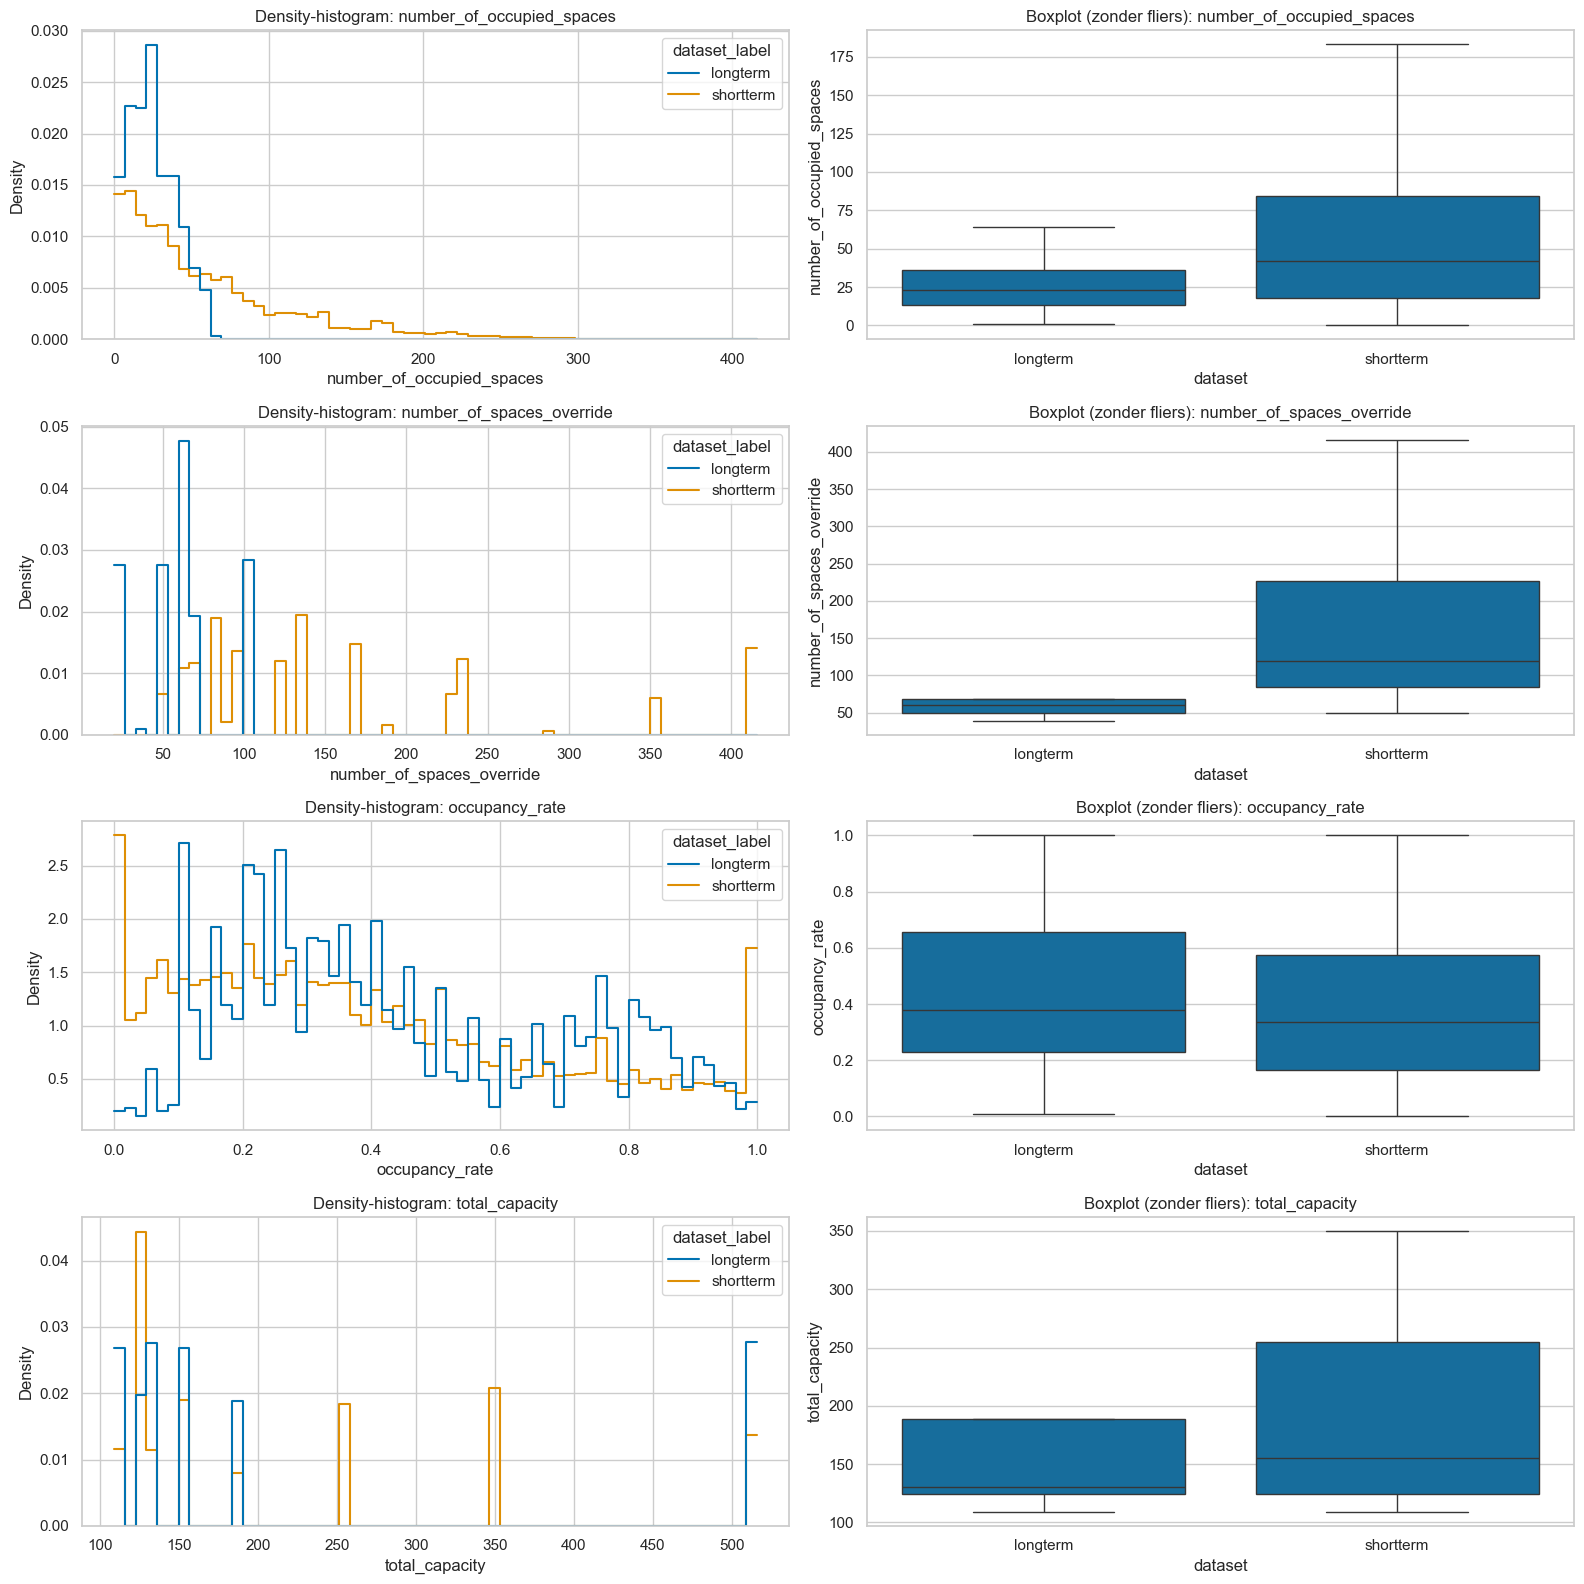

In [4]:
fig, axes = plt.subplots(len(TARGET_VARS), 2, figsize=(16, 4 * len(TARGET_VARS)))

for i, var in enumerate(TARGET_VARS):
    sns.histplot(
        data=analytic_df,
        x=var,
        hue="dataset_label",
        bins=60,
        stat="density",
        common_norm=False,
        element="step",
        fill=False,
        ax=axes[i, 0],
    )
    axes[i, 0].set_title(f"Density-histogram: {var}")
    axes[i, 0].set_xlabel(var)

    sns.boxplot(
        data=analytic_df,
        x="dataset_label",
        y=var,
        showfliers=False,
        ax=axes[i, 1],
    )
    axes[i, 1].set_title(f"Boxplot (zonder fliers): {var}")
    axes[i, 1].set_xlabel("dataset")

plt.tight_layout()
plt.show()

**Interpretatie**

Globaal zien we duidelijke schaalverschillen tussen absolute bezetting (`number_of_occupied_spaces`) en genormaliseerde bezetting (`occupancy_rate`). De absolute telvariabelen tonen sterkere rechtsscheefheid, terwijl `occupancy_rate` compacter en beter vergelijkbaar tussen parkings is.

IQR-outlierpercentages zijn voor `occupancy_rate` laag, maar voor capaciteitsgerelateerde variabelen inhoudelijk minder interpreteerbaar als “fout”, omdat heterogene parkinggroottes structureel extreme waarden kunnen genereren.

**Hypothese status**
- H2: Occupancy-gedrag is tussen shortterm en longterm identiek op globaal distributieniveau. **Genuanceerd verworpen**.
- H3: Absolute bezetting is zonder normalisatie direct vergelijkbaar over parkings. **Verworpen**.

**Volgende logische stap**
- Distributies uitsplitsen per gevraagde segmenten (`kind`, `parking_type`, `parking_location_category`, `year`).

## 3. Distributies per segment

In [5]:
def grouped_distribution_summary(
    df: pd.DataFrame,
    group_cols: list[str],
    variables: list[str],
) -> pd.DataFrame:
    rows = []
    for var in variables:
        grouped = df.groupby(group_cols, dropna=False)[var]
        for key, s in grouped:
            if not isinstance(key, tuple):
                key = (key,)
            row = {col: value for col, value in zip(group_cols, key)}
            row["variable"] = var
            row["n"] = int(s.shape[0])
            row["mean"] = float(s.mean())
            row["median"] = float(s.median())
            row["std"] = float(s.std())
            row["iqr"] = float(s.quantile(0.75) - s.quantile(0.25))
            row["skew"] = float(s.skew())
            row["q95"] = float(s.quantile(0.95))
            row["iqr_outlier_pct"] = iqr_outlier_pct(s)
            rows.append(row)
    return pd.DataFrame(rows)


segment_summaries = {
    "per_kind": grouped_distribution_summary(analytic_df, ["dataset_label", "kind"], TARGET_VARS),
    "per_parking_type": grouped_distribution_summary(analytic_df, ["dataset_label", "parking_type"], TARGET_VARS),
    "per_location_category": grouped_distribution_summary(analytic_df, ["dataset_label", "parking_location_category"], TARGET_VARS),
    "per_year": grouped_distribution_summary(analytic_df, ["dataset_label", "year"], TARGET_VARS),
}

for name, table in segment_summaries.items():
    print(f"\n=== {name} ===")
    display(table.round(4))

print("\nUnieke cardinaliteit van segmentkolommen")
for col in ["kind", "parking_type", "parking_location_category", "year"]:
    values = analytic_df[col].dropna().unique()
    print(f"{col}: {len(values)} unieke waarden -> {sorted(values.tolist())[:10]}")


=== per_kind ===


,dataset_label,kind,variable,n,mean,median,std,iqr,skew,q95,iqr_outlier_pct
0,longterm,longterm,number_of_occupied_spaces,46643,24.8831,23.0000,15.0532,23.0000,0.4437,53.0000,0.0000
1,shortterm,shortterm,number_of_occupied_spaces,284524,60.9654,42.0000,58.8174,66.0000,1.6075,181.0000,4.7834
2,longterm,longterm,number_of_spaces_override,46643,59.9436,60.0000,24.9832,19.0000,0.0223,100.0000,36.9209
3,shortterm,shortterm,number_of_spaces_override,284524,160.8176,120.0000,107.0223,142.0000,1.2889,416.0000,0.0000
4,longterm,longterm,occupancy_rate,46643,0.4372,0.3800,0.2538,0.4262,0.4837,0.8906,0.0000
5,shortterm,shortterm,occupancy_rate,284524,0.3894,0.3365,0.2764,0.4086,0.5709,0.9294,0.0000
6,longterm,longterm,total_capacity,46643,209.8508,130.0000,149.0560,65.0000,1.5054,516.0000,18.7595
7,shortterm,shortterm,total_capacity,284524,216.0418,155.0000,124.4745,131.0000,1.2698,516.0000,9.2572



=== per_parking_type ===


,dataset_label,parking_type,variable,n,mean,median,std,iqr,skew,q95,iqr_outlier_pct
0,longterm,Car Parking,number_of_occupied_spaces,46643,24.8831,23.0000,15.0532,23.0000,0.4437,53.0000,0.0000
1,shortterm,Car Parking,number_of_occupied_spaces,284524,60.9654,42.0000,58.8174,66.0000,1.6075,181.0000,4.7834
2,longterm,Car Parking,number_of_spaces_override,46643,59.9436,60.0000,24.9832,19.0000,0.0223,100.0000,36.9209
3,shortterm,Car Parking,number_of_spaces_override,284524,160.8176,120.0000,107.0223,142.0000,1.2889,416.0000,0.0000
4,longterm,Car Parking,occupancy_rate,46643,0.4372,0.3800,0.2538,0.4262,0.4837,0.8906,0.0000
5,shortterm,Car Parking,occupancy_rate,284524,0.3894,0.3365,0.2764,0.4086,0.5709,0.9294,0.0000
6,longterm,Car Parking,total_capacity,46643,209.8508,130.0000,149.0560,65.0000,1.5054,516.0000,18.7595
7,shortterm,Car Parking,total_capacity,284524,216.0418,155.0000,124.4745,131.0000,1.2698,516.0000,9.2572



=== per_location_category ===


,dataset_label,parking_location_category,variable,n,mean,median,std,iqr,skew,q95,iqr_outlier_pct
0,longterm,centrum,number_of_occupied_spaces,25681,21.5473,21.0000,13.0635,22.0000,0.1694,43.0000,0.0000
1,longterm,rand,number_of_occupied_spaces,8750,28.4278,26.0000,9.5985,11.0000,0.9217,48.0000,4.4457
2,longterm,vesten,number_of_occupied_spaces,12212,29.3584,24.0000,19.7027,39.0000,0.2665,59.0000,0.0000
3,shortterm,centrum,number_of_occupied_spaces,152287,59.2526,48.0000,47.2198,63.0000,1.0592,155.0000,2.2096
4,shortterm,rand,number_of_occupied_spaces,26339,161.8762,152.0000,74.6622,115.0000,0.4817,293.0000,0.2126
5,shortterm,vesten,number_of_occupied_spaces,105898,38.3299,27.0000,40.6533,40.0000,1.9889,131.0000,6.6234
6,longterm,centrum,number_of_spaces_override,25681,43.5026,50.0000,16.9896,40.0000,-0.5437,60.0000,0.0000
7,longterm,rand,number_of_spaces_override,8750,100.0000,100.0000,0.0000,0.0000,0.0000,100.0000,0.0000
8,longterm,vesten,number_of_spaces_override,12212,65.8171,64.0000,4.9328,5.0000,-3.8679,69.0000,2.4730
9,shortterm,centrum,number_of_spaces_override,152287,130.8788,120.0000,61.6737,55.0000,0.6569,235.0000,23.3809



=== per_year ===


,dataset_label,year,variable,n,mean,median,std,iqr,skew,q95,iqr_outlier_pct
0,longterm,2024,number_of_occupied_spaces,46643,24.8831,23.0000,15.0532,23.0000,0.4437,53.0000,0.0000
1,shortterm,2018,number_of_occupied_spaces,5,101.0000,85.0000,71.0634,82.0000,0.8376,192.2000,0.0000
2,shortterm,2019,number_of_occupied_spaces,33000,61.1807,47.0000,46.2197,55.0000,1.2838,158.0000,4.2273
3,shortterm,2020,number_of_occupied_spaces,32741,53.4383,42.0000,40.2265,49.0000,1.2309,129.0000,2.7916
4,shortterm,2021,number_of_occupied_spaces,13630,61.7478,53.0000,36.2395,47.0000,1.0589,134.0000,2.1864
5,shortterm,2022,number_of_occupied_spaces,12762,69.8327,62.0000,40.8233,53.0000,1.1413,149.0000,2.5701
6,shortterm,2023,number_of_occupied_spaces,39980,74.1557,59.0000,63.4628,92.0000,1.0316,203.0000,1.1906
7,shortterm,2024,number_of_occupied_spaces,57116,48.5172,28.0000,52.2016,59.0000,1.7132,155.0000,4.7255
8,shortterm,2025,number_of_occupied_spaces,87600,64.7669,34.0000,72.2917,76.0000,1.6012,223.0000,6.3539
9,shortterm,2026,number_of_occupied_spaces,7690,56.5376,33.0000,59.3555,59.0000,1.4129,185.5500,8.6086



Unieke cardinaliteit van segmentkolommen
kind: 2 unieke waarden -> ['longterm', 'shortterm']
parking_type: 1 unieke waarden -> ['Car Parking']
parking_location_category: 3 unieke waarden -> ['centrum', 'rand', 'vesten']
year: 9 unieke waarden -> [2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025, 2026]


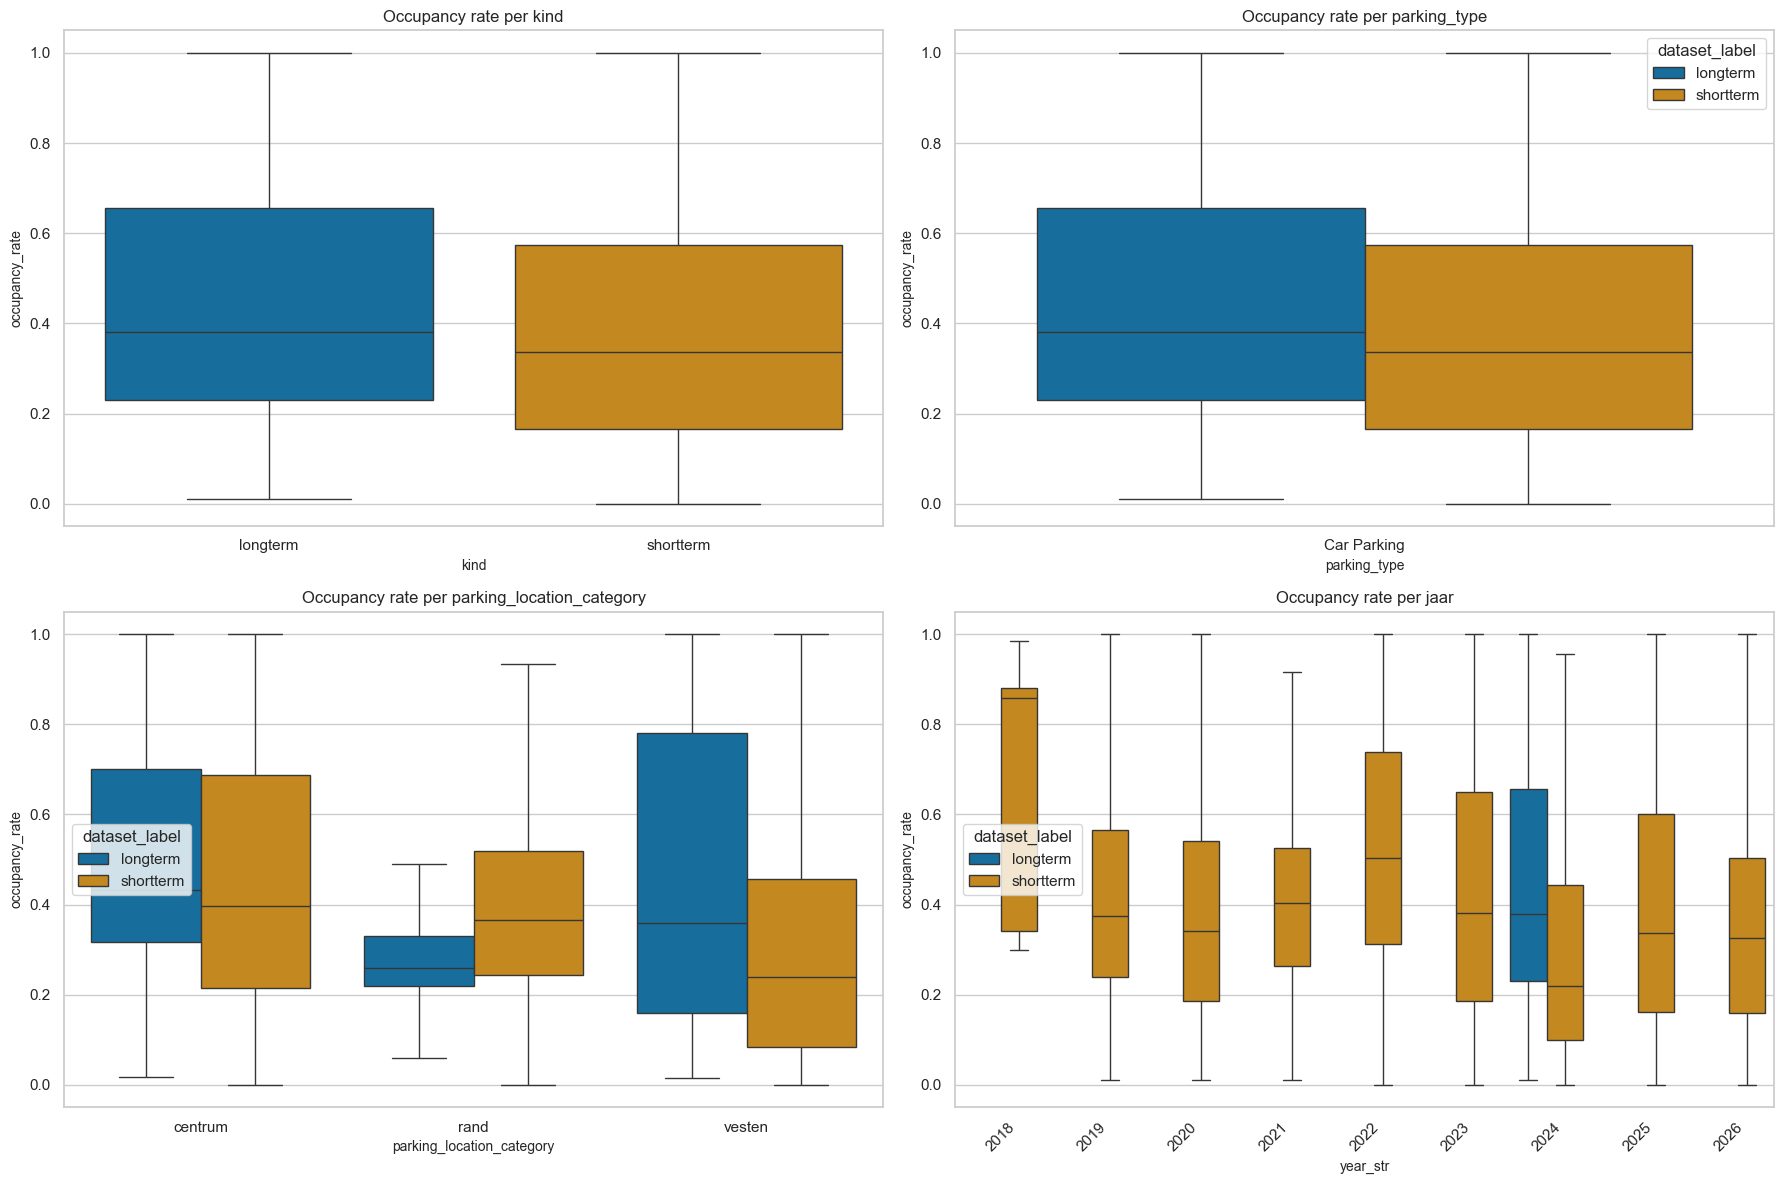

Jaarlijkse samenvatting (mean/median/std/q95) voor kernvariabelen


number_of_occupied_spaces_mean  \
dataset_label year                                   
longterm      2024                         24.8831   
shortterm     2018                        101.0000   
              2019                         61.1807   
              2020                         53.4383   
              2021                         61.7478   
              2022                         69.8327   
              2023                         74.1557   
              2024                         48.5172   
              2025                         64.7669   
              2026                         56.5376   

                    number_of_occupied_spaces_median  \
dataset_label year                                     
longterm      2024                              23.0   
shortterm     2018                              85.0   
              2019                              47.0   
              2020                              42.0   
              2021                              53.0   
              2022                              62.0   
              2023                              59.0   
              2024                              28.0   
              2025                              34.0   
              2026                              33.0   

                    number_of_occupied_spaces_std  \
dataset_label year                                  
longterm      2024                        15.0532   
shortterm     2018                        71.0634   
              2019                        46.2197   
              2020                        40.2265   
              2021                        36.2395   
              2022                        40.8233   
              2023                        63.4628   
              2024                        52.2016   
              2025                        72.2917   
              2026                        59.3555   

                    number_of_occupied_spaces_q95  \
dataset_label year                                  
longterm      2024                          53.00   
shortterm     2018                         192.20   
              2019                         158.00   
              2020                         129.00   
              2021                         134.00   
              2022                         149.00   
              2023                         203.00   
              2024                         155.00   
              2025                         223.00   
              2026                         185.55   

                    number_of_spaces_override_mean  \
dataset_label year                                   
longterm      2024                         59.9436   
shortterm     2018                        145.0000   
              2019                        152.5283   
              2020                        149.9393   
              2021                        156.7372   
              2022                        139.7627   
              2023                        181.6318   
              2024                        169.2457   
              2025                        157.1317   
              2026                        156.0693   

                    number_of_spaces_override_median  \
dataset_label year                                     
longterm      2024                              60.0   
shortterm     2018                             135.0   
              2019                             135.0   
              2020                             135.0   
              2021                             171.0   
              2022                             135.0   
              2023                             120.0   
              2024                             120.0   
              2025                             109.5   
              2026                             100.0   

                    number_of_spaces_override_std  \
dataset_label year                               

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(18, 12))

sns.boxplot(
    data=analytic_df,
    x="kind",
    y="occupancy_rate",
    hue="dataset_label",
    showfliers=False,
    ax=axes[0, 0],
)
axes[0, 0].set_title("Occupancy rate per kind")

sns.boxplot(
    data=analytic_df,
    x="parking_type",
    y="occupancy_rate",
    hue="dataset_label",
    showfliers=False,
    ax=axes[0, 1],
)
axes[0, 1].set_title("Occupancy rate per parking_type")

location_order = sorted(analytic_df["parking_location_category"].dropna().unique().tolist())
sns.boxplot(
    data=analytic_df,
    x="parking_location_category",
    y="occupancy_rate",
    hue="dataset_label",
    order=location_order,
    showfliers=False,
    ax=axes[1, 0],
)
axes[1, 0].set_title("Occupancy rate per parking_location_category")

year_plot_df = analytic_df.copy()
year_plot_df["year_str"] = year_plot_df["year"].astype(str)
year_order = sorted(year_plot_df["year_str"].dropna().unique().tolist())
sns.boxplot(
    data=year_plot_df,
    x="year_str",
    y="occupancy_rate",
    hue="dataset_label",
    order=year_order,
    showfliers=False,
    ax=axes[1, 1],
)
axes[1, 1].set_title("Occupancy rate per jaar")
axes[1, 1].tick_params(axis="x", rotation=45)

for ax in axes.flatten():
    ax.set_xlabel(ax.get_xlabel(), fontsize=10)
    ax.set_ylabel("occupancy_rate", fontsize=10)

plt.tight_layout()
plt.show()


yearly_target_summary = (
    analytic_df.groupby(["dataset_label", "year"])[TARGET_VARS]
    .agg(["mean", "median", "std", lambda s: s.quantile(0.95)])
)
yearly_target_summary.columns = [
    "_".join([c if isinstance(c, str) else "q95" for c in col]).replace("_<lambda_0>", "_q95")
    for col in yearly_target_summary.columns
]
print("Jaarlijkse samenvatting (mean/median/std/q95) voor kernvariabelen")
display(yearly_target_summary.round(4))

**Interpretatie**

Segmentaties naar `kind` en `parking_type` blijken beperkt discriminatief in deze extracten (lage cardinaliteit). De locatiecategorie en jaarsegmentatie zijn daarentegen informatief: ze tonen duidelijke niveau- en spreidingsverschillen in bezettingsdynamiek.

De jaardynamiek in shortterm is niet stationair op descriptief niveau, wat latere temporele analyses (trend, regime shifts, seasonality) noodzakelijk maakt.

**Hypothese status**
- H4: Locatiecategorie heeft weinig invloed op globale bezettingsverdelingen. **Voorlopig verworpen**.
- H5: Jaar-op-jaar descriptieve stabiliteit is voldoende om tijdsinvariante aannames te maken. **Verworpen**.

**Volgende logische stap**
- Een expliciete shortterm-longterm vergelijking maken op gemiddelde bezetting, variabiliteit, piekgedrag en stabiliteit.

## 4. Expliciete vergelijking shortterm vs longterm

In [7]:
def occupancy_comparison_table(df: pd.DataFrame) -> pd.DataFrame:
    base = df.groupby("dataset_label")["occupancy_rate"].agg(
        mean="mean",
        median="median",
        std="std",
        iqr=lambda s: s.quantile(0.75) - s.quantile(0.25),
        q95=lambda s: s.quantile(0.95),
        q99=lambda s: s.quantile(0.99),
        max="max",
        pct_ge_90=lambda s: (s >= 0.90).mean() * 100,
        pct_ge_95=lambda s: (s >= 0.95).mean() * 100,
        cv=lambda s: s.std() / s.mean() if s.mean() != 0 else np.nan,
    )

    stability_rows = []
    for dataset_label, grp in df.groupby("dataset_label"):
        ordered = grp.sort_values(["parking_id", "rounded_hour"])
        delta = ordered.groupby("parking_id")["occupancy_rate"].diff().abs()
        stability_rows.append(
            {
                "dataset_label": dataset_label,
                "mean_abs_hourly_change": float(delta.mean()),
                "median_abs_hourly_change": float(delta.median()),
                "p90_abs_hourly_change": float(delta.quantile(0.90)),
                "pct_small_changes_le_0_05": float((delta <= 0.05).mean() * 100),
                "pct_large_changes_ge_0_20": float((delta >= 0.20).mean() * 100),
            }
        )
    stability = pd.DataFrame(stability_rows).set_index("dataset_label")

    return base.join(stability)


comparison = occupancy_comparison_table(analytic_df)
display(comparison.round(4))

st = analytic_df.loc[analytic_df["dataset_label"] == "shortterm", "occupancy_rate"].dropna()
lt = analytic_df.loc[analytic_df["dataset_label"] == "longterm", "occupancy_rate"].dropna()

mean_diff = float(lt.mean() - st.mean())
pooled_std = float(np.sqrt((st.var(ddof=1) + lt.var(ddof=1)) / 2))
cohen_d = mean_diff / pooled_std if pooled_std != 0 else np.nan

print(f"Mean difference (longterm - shortterm): {mean_diff:.4f}")
print(f"Cohen's d: {cohen_d:.4f}")

,mean,median,std,iqr,q95,q99,max,pct_ge_90,pct_ge_95,cv,mean_abs_hourly_change,median_abs_hourly_change,p90_abs_hourly_change,pct_small_changes_le_0_05,pct_large_changes_ge_0_20
dataset_label,,,,,,,,,,,,,,,
longterm,0.4372,0.3800,0.2538,0.4262,0.8906,0.96,1.0,4.5559,1.6015,0.5806,0.0419,0.0167,0.1000,79.0730,4.7467
shortterm,0.3894,0.3365,0.2764,0.4086,0.9294,1.00,1.0,6.4388,4.1297,0.7097,0.0573,0.0235,0.1625,65.4838,6.8026


Mean difference (longterm - shortterm): 0.0478
Cohen's d: 0.1803


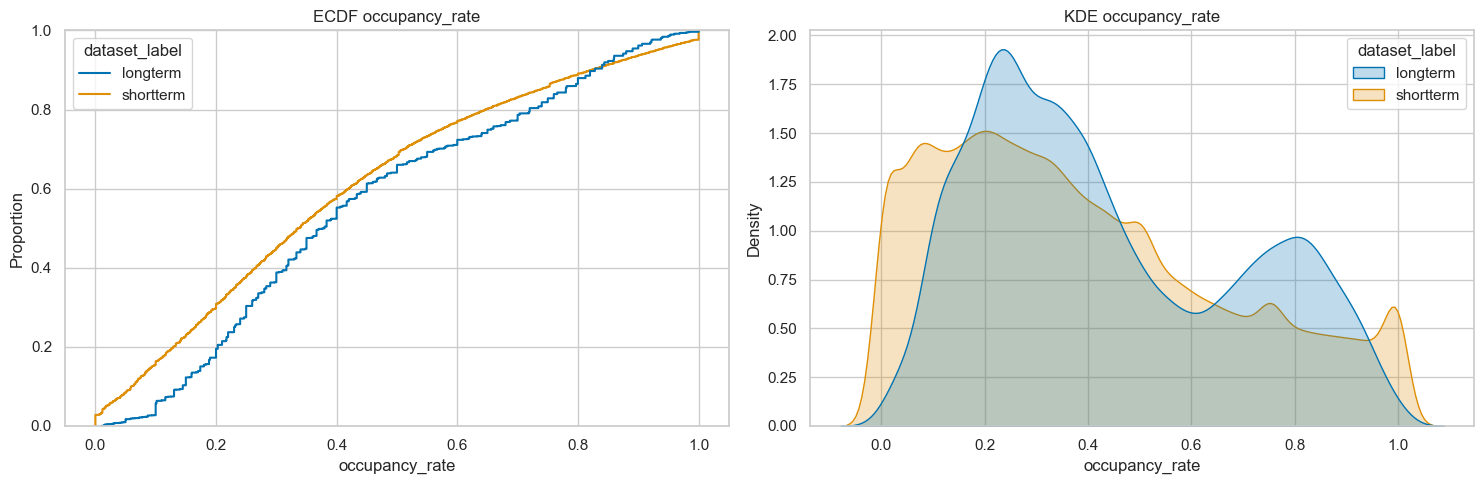

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sns.ecdfplot(data=analytic_df, x="occupancy_rate", hue="dataset_label", ax=axes[0])
axes[0].set_title("ECDF occupancy_rate")

sns.kdeplot(
    data=analytic_df,
    x="occupancy_rate",
    hue="dataset_label",
    common_norm=False,
    fill=True,
    alpha=0.25,
    ax=axes[1],
)
axes[1].set_title("KDE occupancy_rate")

plt.tight_layout()
plt.show()

**Interpretatie**

Longterm heeft een hoger gemiddeld bezettingsniveau, maar shortterm toont hogere relatieve variabiliteit en zwaardere piekstaarten (meer uren in zeer hoge bezetting). Stabiliteitsmaten op basis van opeenvolgende uurverschillen wijzen op dynamischer schommelingen in shortterm.

Het gemiddelde verschil in occupancy-rate is descriptief aanwezig maar met beperkte gestandaardiseerde effectgrootte; het verschil zit dus niet alleen in niveau, maar vooral ook in dynamisch profiel (variabiliteit/piekgedrag).

**Hypothese status**
- H6: Longterm en shortterm verschillen enkel in niveau, niet in dynamiek. **Verworpen**.
- H7: Shortterm vertoont meer piekgevoeligheid dan longterm. **Voorlopig ondersteund**.

**Volgende logische stap**
- Parkingniveau-analyses toevoegen om globale patronen te ontleden in concrete parkeerprofielen.

## 5. Descriptief op parkingniveau

In [9]:
parking_stats = (
    analytic_df.groupby(["dataset_label", "parking_id"])
    .agg(
        n_obs=("occupancy_rate", "size"),
        mean_occupancy=("occupancy_rate", "mean"),
        std_occupancy=("occupancy_rate", "std"),
        iqr_occupancy=("occupancy_rate", lambda s: s.quantile(0.75) - s.quantile(0.25)),
        q95_occupancy=("occupancy_rate", lambda s: s.quantile(0.95)),
        q99_occupancy=("occupancy_rate", lambda s: s.quantile(0.99)),
        pct_hours_ge_90=("occupancy_rate", lambda s: (s >= 0.9).mean() * 100),
        mean_abs_hourly_change=("abs_hourly_occ_change", "mean"),
    )
    .reset_index()
)
parking_stats["cv_occupancy"] = parking_stats["std_occupancy"] / parking_stats["mean_occupancy"]


def top_bottom(table: pd.DataFrame, metric: str, n: int = 3) -> pd.DataFrame:
    parts = []
    for dataset_label, grp in table.groupby("dataset_label"):
        g = grp.sort_values(metric, ascending=False)
        top = g.head(n).copy()
        top["rank_group"] = "top"

        bottom = g.tail(n).sort_values(metric, ascending=True).copy()
        bottom["rank_group"] = "bottom"

        parts.append(pd.concat([top, bottom], ignore_index=True))
    return pd.concat(parts, ignore_index=True)


print("Top/bottom qua gemiddelde bezetting")
display(top_bottom(parking_stats, "mean_occupancy", n=3).round(4))

print("Top/bottom qua variabiliteit (std)")
display(top_bottom(parking_stats, "std_occupancy", n=3).round(4))

print("Top/bottom qua piekbelasting (q99)")
display(top_bottom(parking_stats, "q99_occupancy", n=3).round(4))

print("Volledige parkingstatistiek")
display(parking_stats.sort_values(["dataset_label", "mean_occupancy"], ascending=[True, False]).round(4))

Top/bottom qua gemiddelde bezetting


,dataset_label,parking_id,n_obs,mean_occupancy,std_occupancy,iqr_occupancy,q95_occupancy,q99_occupancy,pct_hours_ge_90,mean_abs_hourly_change,cv_occupancy,rank_group
0,longterm,P Komet,5962,0.7203,0.2200,0.2344,0.9531,0.9844,16.5884,0.0250,0.3054,top
1,longterm,P Hoogstraat,8483,0.6832,0.1928,0.2200,0.9200,0.9800,8.7351,0.0277,0.2821,top
2,longterm,P Tinel,302,0.5101,0.3421,0.7628,0.9487,1.0000,21.5232,0.1014,0.6707,top
3,longterm,P Maarten,5948,0.1892,0.0895,0.0870,0.3913,0.4348,0.0000,0.0107,0.4729,bottom
4,longterm,P Keerdok,8750,0.2843,0.0960,0.1100,0.4800,0.5500,0.0000,0.0188,0.3376,bottom
5,longterm,P Grote Markt,8471,0.3794,0.2466,0.4000,0.8500,0.9650,3.8956,0.1311,0.6499,bottom
6,shortterm,P Grote Markt,36649,0.4848,0.3131,0.5852,1.0000,1.0000,14.1368,0.0978,0.6458,top
7,shortterm,P Veemarkt,35370,0.4831,0.2761,0.4343,0.9495,1.0000,8.4224,0.0873,0.5714,top
8,shortterm,P Kathedraal,22179,0.4814,0.3449,0.6714,1.0000,1.0000,19.6718,0.1004,0.7164,top
9,shortterm,P Maarten,15473,0.0971,0.1012,0.1750,0.2917,0.3417,0.0000,0.0092,1.0422,bottom


Top/bottom qua variabiliteit (std)


,dataset_label,parking_id,n_obs,mean_occupancy,std_occupancy,iqr_occupancy,q95_occupancy,q99_occupancy,pct_hours_ge_90,mean_abs_hourly_change,cv_occupancy,rank_group
0,longterm,P Tinel,302,0.5101,0.3421,0.7628,0.9487,1.0000,21.5232,0.1014,0.6707,top
1,longterm,P Grote Markt,8471,0.3794,0.2466,0.4000,0.8500,0.9650,3.8956,0.1311,0.6499,top
2,longterm,P Komet,5962,0.7203,0.2200,0.2344,0.9531,0.9844,16.5884,0.0250,0.3054,top
3,longterm,P Maarten,5948,0.1892,0.0895,0.0870,0.3913,0.4348,0.0000,0.0107,0.4729,bottom
4,longterm,P Keerdok,8750,0.2843,0.0960,0.1100,0.4800,0.5500,0.0000,0.0188,0.3376,bottom
5,longterm,P Kathedraal,8727,0.3806,0.1091,0.1167,0.5667,0.6790,0.0000,0.0233,0.2865,bottom
6,shortterm,P Kathedraal,22179,0.4814,0.3449,0.6714,1.0000,1.0000,19.6718,0.1004,0.7164,top
7,shortterm,P Grote Markt,36649,0.4848,0.3131,0.5852,1.0000,1.0000,14.1368,0.0978,0.6458,top
8,shortterm,P Veemarkt,35370,0.4831,0.2761,0.4343,0.9495,1.0000,8.4224,0.0873,0.5714,top
9,shortterm,P Maarten,15473,0.0971,0.1012,0.1750,0.2917,0.3417,0.0000,0.0092,1.0422,bottom


Top/bottom qua piekbelasting (q99)


,dataset_label,parking_id,n_obs,mean_occupancy,std_occupancy,iqr_occupancy,q95_occupancy,q99_occupancy,pct_hours_ge_90,mean_abs_hourly_change,cv_occupancy,rank_group
0,longterm,P Tinel,302,0.5101,0.3421,0.7628,0.9487,1.0000,21.5232,0.1014,0.6707,top
1,longterm,P Komet,5962,0.7203,0.2200,0.2344,0.9531,0.9844,16.5884,0.0250,0.3054,top
2,longterm,P Hoogstraat,8483,0.6832,0.1928,0.2200,0.9200,0.9800,8.7351,0.0277,0.2821,top
3,longterm,P Maarten,5948,0.1892,0.0895,0.0870,0.3913,0.4348,0.0000,0.0107,0.4729,bottom
4,longterm,P Keerdok,8750,0.2843,0.0960,0.1100,0.4800,0.5500,0.0000,0.0188,0.3376,bottom
5,longterm,P Kathedraal,8727,0.3806,0.1091,0.1167,0.5667,0.6790,0.0000,0.0233,0.2865,bottom
6,shortterm,P Grote Markt,36649,0.4848,0.3131,0.5852,1.0000,1.0000,14.1368,0.0978,0.6458,top
7,shortterm,P Hoogstraat,22483,0.2924,0.2294,0.3000,0.7800,1.0000,2.8955,0.0437,0.7843,top
8,shortterm,P Kathedraal,22179,0.4814,0.3449,0.6714,1.0000,1.0000,19.6718,0.1004,0.7164,top
9,shortterm,P Maarten,15473,0.0971,0.1012,0.1750,0.2917,0.3417,0.0000,0.0092,1.0422,bottom


Volledige parkingstatistiek


,dataset_label,parking_id,n_obs,mean_occupancy,std_occupancy,iqr_occupancy,q95_occupancy,q99_occupancy,pct_hours_ge_90,mean_abs_hourly_change,cv_occupancy
4,longterm,P Komet,5962,0.7203,0.2200,0.2344,0.9531,0.9844,16.5884,0.0250,0.3054
1,longterm,P Hoogstraat,8483,0.6832,0.1928,0.2200,0.9200,0.9800,8.7351,0.0277,0.2821
6,longterm,P Tinel,302,0.5101,0.3421,0.7628,0.9487,1.0000,21.5232,0.1014,0.6707
2,longterm,P Kathedraal,8727,0.3806,0.1091,0.1167,0.5667,0.6790,0.0000,0.0233,0.2865
0,longterm,P Grote Markt,8471,0.3794,0.2466,0.4000,0.8500,0.9650,3.8956,0.1311,0.6499
3,longterm,P Keerdok,8750,0.2843,0.0960,0.1100,0.4800,0.5500,0.0000,0.0188,0.3376
5,longterm,P Maarten,5948,0.1892,0.0895,0.0870,0.3913,0.4348,0.0000,0.0107,0.4729
8,shortterm,P Grote Markt,36649,0.4848,0.3131,0.5852,1.0000,1.0000,14.1368,0.0978,0.6458
16,shortterm,P Veemarkt,35370,0.4831,0.2761,0.4343,0.9495,1.0000,8.4224,0.0873,0.5714
10,shortterm,P Kathedraal,22179,0.4814,0.3449,0.6714,1.0000,1.0000,19.6718,0.1004,0.7164


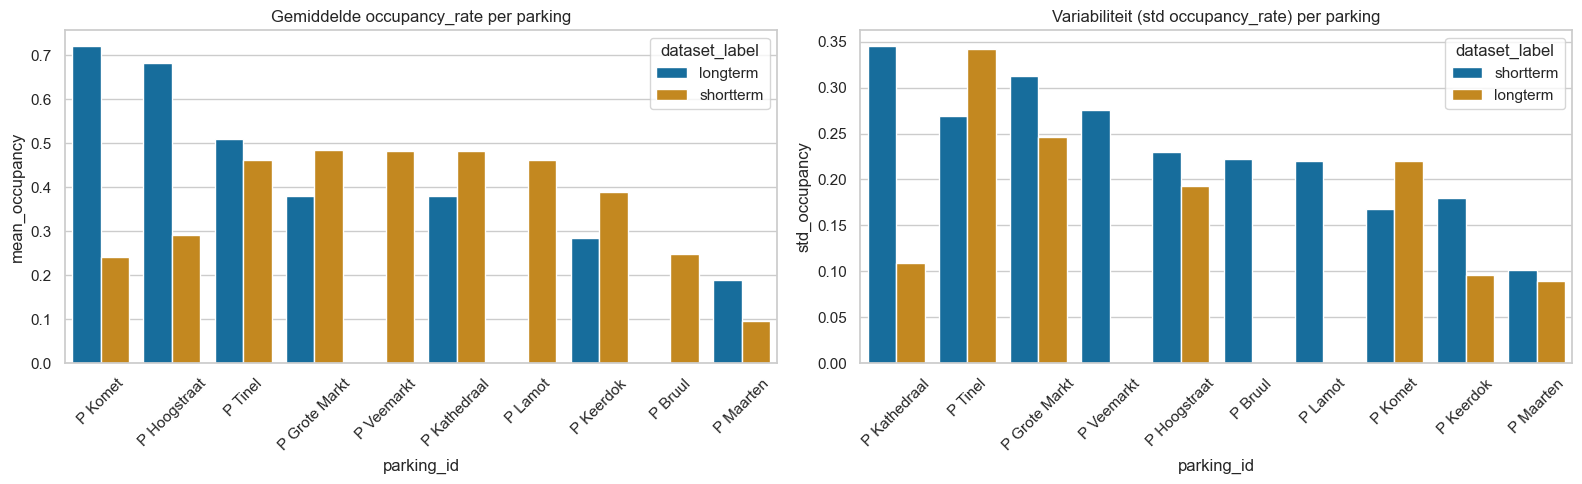

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

sns.barplot(
    data=parking_stats.sort_values("mean_occupancy", ascending=False),
    x="parking_id",
    y="mean_occupancy",
    hue="dataset_label",
    ax=axes[0],
)
axes[0].set_title("Gemiddelde occupancy_rate per parking")
axes[0].tick_params(axis="x", rotation=45)

sns.barplot(
    data=parking_stats.sort_values("std_occupancy", ascending=False),
    x="parking_id",
    y="std_occupancy",
    hue="dataset_label",
    ax=axes[1],
)
axes[1].set_title("Variabiliteit (std occupancy_rate) per parking")
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

**Interpretatie**

Parkingniveau bevestigt dat globale gemiddelden verschillende lokale regimes maskeren: sommige parkings combineren hoog gemiddelde met hoge volatiliteit en piekdruk, terwijl andere een lager maar stabieler profiel hebben.

Deze heterogeniteit ondersteunt een tier-/parking-specifieke EDA-strategie in volgende notebooks.

**Hypothese status**
- H8: Een enkel globaal bezettingsprofiel volstaat als representatie van alle parkings. **Verworpen**.

**Volgende logische stap**
- Occupancy-rate expliciet beoordelen als hoofdtarget, inclusief methodologische kanttekeningen voor vervolg-EDA en feature engineering.

## 6. Is occupancy_rate een geschikte hoofdtarget?

In [11]:
target_checks = []
correlation_rows = []

for dataset_label, grp in analytic_df.groupby("dataset_label"):
    occ = pd.to_numeric(grp["number_of_occupied_spaces"], errors="coerce")
    cap_override = pd.to_numeric(grp["number_of_spaces_override"], errors="coerce")
    occ_rate = pd.to_numeric(grp["occupancy_rate"], errors="coerce")

    reconstructed = occ / cap_override
    abs_diff = (occ_rate - reconstructed).abs()

    cap_nunique_per_parking = grp.groupby("parking_id")["number_of_spaces_override"].nunique()

    target_checks.append(
        {
            "dataset_label": dataset_label,
            "missing_pct_occupancy_rate": float(occ_rate.isna().mean() * 100),
            "pct_outside_0_1": float(((occ_rate < 0) | (occ_rate > 1)).mean() * 100),
            "mean_abs_reconstruction_error": float(abs_diff.mean()),
            "max_abs_reconstruction_error": float(abs_diff.max()),
            "parkings_with_variable_capacity_override": int((cap_nunique_per_parking > 1).sum()),
            "max_nunique_capacity_override_per_parking": int(cap_nunique_per_parking.max()),
        }
    )

    corr_occ_rate_occ = grp[["occupancy_rate", "number_of_occupied_spaces"]].corr().iloc[0, 1]
    corr_occ_cap = grp[["number_of_occupied_spaces", "number_of_spaces_override"]].corr().iloc[0, 1]
    corr_rate_cap = grp[["occupancy_rate", "number_of_spaces_override"]].corr().iloc[0, 1]

    correlation_rows.append(
        {
            "dataset_label": dataset_label,
            "corr(occupancy_rate, occupied_spaces)": float(corr_occ_rate_occ),
            "corr(occupied_spaces, spaces_override)": float(corr_occ_cap),
            "corr(occupancy_rate, spaces_override)": float(corr_rate_cap),
        }
    )


target_check_table = pd.DataFrame(target_checks).set_index("dataset_label")
correlation_table = pd.DataFrame(correlation_rows).set_index("dataset_label")

print("Target-geschiktheidschecks")
display(target_check_table.round(6))

print("Correlatiecontext")
display(correlation_table.round(4))

Target-geschiktheidschecks


,missing_pct_occupancy_rate,pct_outside_0_1,mean_abs_reconstruction_error,max_abs_reconstruction_error,parkings_with_variable_capacity_override,max_nunique_capacity_override_per_parking
dataset_label,,,,,,
longterm,0.0,0.0,0.0,0.0,0,1
shortterm,0.0,0.0,0.0,0.0,8,5


Correlatiecontext


,"corr(occupancy_rate, occupied_spaces)","corr(occupied_spaces, spaces_override)","corr(occupancy_rate, spaces_override)"
dataset_label,,,
longterm,0.7895,0.3545,-0.2089
shortterm,0.6030,0.6595,-0.0559


**Interpretatie**

`occupancy_rate` is technisch een sterke hoofdtarget voor verdere EDA: volledig beschikbaar, gebonden in `[0,1]`, en exact consistent met `occupied_spaces / spaces_override`.

Kanttekeningen blijven belangrijk:
- Als ratio is `occupancy_rate` begrensd en potentieel niet-normaal, dus lineaire aannames moeten voorzichtig gebruikt worden.
- Veranderingen in `number_of_spaces_override` (met name in shortterm) kunnen de noemer wijzigen en ratiovergelijkingen doorheen de tijd beïnvloeden.
- Zeer hoge bezetting (staartgedrag) vraagt aparte analyse (thresholds, piekregimes) naast gemiddelde effecten.

**Hypothese status**
- H9: `occupancy_rate` is ongeschikt als hoofdtarget. **Verworpen**.
- H10: `occupancy_rate` kan zonder aanvullende context overal uniform geïnterpreteerd worden. **Verworpen**.

**Volgende logische stap**
- De globale patronen en implicaties vertalen naar concrete hypothesen voor temporal, spatial en external-factor notebooks.

## 7. Synthese en vervolg

### Welke globale patronen zijn al zichtbaar?
1. Shortterm en longterm verschillen niet alleen in gemiddeld niveau, maar ook in dynamiek: shortterm is relatief volatieler en vertoont zwaardere piekstaarten.
2. Absolute bezettingsaantallen worden sterk mee bepaald door parkinggrootte, waardoor normalisatie via `occupancy_rate` cruciaal is voor vergelijkbaarheid.
3. Parking- en locatieheterogeniteit is substantieel: globale gemiddelden verbergen duidelijke lokale regimes.
4. Jaardistributies in shortterm tonen descriptieve regimeverschillen, wat tijdsinvariante aannames verzwakt.

### Welke hypothesen lijken plausibel?
1. Piekdruk is niet uniform verdeeld, maar geconcentreerd in specifieke parkings en locatiecategorieen.
2. Temporal drivers (uur, weekpatroon, seizoen, jaarregime) interageren met parking-specifieke baselinebezetting.
3. Externe factoren (events, weer, kalender) hebben vermoedelijk heterogene effecten afhankelijk van baseline-occupancy en locatie.
4. Stabiliteitsprofielen (uur-op-uur verandering) kunnen een bruikbare segmentatie-as vormen naast gemiddeld bezettingsniveau.

### Welke verdere analyses zijn noodzakelijk?
1. Temporal notebook: regimewissels, seizoenscomponenten, trendbreuken en piekregimes expliciet modelleren.
2. Spatial notebook: parking-specifieke baseline, spreiding en piekbelasting koppelen aan locatiecategorie en capaciteit.
3. External-factor notebook: effectheterogeniteit van events/weer/kalender testen met interactietermen en segmentatie.
4. Shortterm-vs-longterm notebook: formele vergelijking van distributievorm, tail-risk en stabiliteitsmaten met sensitiviteitschecks.

## Key findings
1. `occupancy_rate` is descriptief de meest consistente vergelijkingsmaat tussen datasets en parkings.
2. Shortterm bevat een dynamischer bezettingsprofiel dan longterm, met relatief zwaarder piekgedrag.
3. Parkingniveau-heterogeniteit is groot; aggregatie op globaal niveau maskeert relevante verschillen.
4. Locatie en jaar dragen zichtbare descriptieve structuur die later hypothese-gedreven moet worden uitgediept.

## Implications for feature engineering
1. Gebruik `occupancy_rate` als hoofdtarget, maar rapporteer altijd aanvullende piekfeatures (bijv. `% uren >= 0.9`, `q95`, `q99`).
2. Voeg stabiliteitsfeatures toe (bijv. gemiddelde absolute uurverandering, regime-indicatoren voor plotse sprongen).
3. Maak parking-specifieke baselinefeatures (historisch gemiddelde, spreiding, piekindex) in plaats van enkel globale features.
4. Neem noemercontext op: capaciteit en eventuele capaciteitswijzigingen als expliciete features/flags.
5. Overweeg niet-lineaire transformaties of bounded-target-benaderingen bij modelkeuze door de ratio-eigenschappen van de target.

## Open questions for next notebook
1. In welke mate worden de globale verschillen primair gedreven door uur/weekday-seizoen patronen versus structurele parkingverschillen?
2. Welke parkings vertonen de sterkste regimewissels doorheen de tijd?
3. Zijn piekregimes voorspelbaar via kalender- of eventcontext, of eerder via interne dynamiek van individuele parkings?
4. Hoe robuust blijven de descriptieve patronen onder strengere kwaliteitsfilters uit notebook 00?